# Ridership Analysis

The goal of this notebook is to analyze the ridership data for each ace bus, and identify trends and patterns over time.

Goals:

- Load and clean the ridership data
- Visualize ridership trends over time
- Identify peak ridership periods
- Compare ridership across different routes


## Setup and Analysis


In [44]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..", "..")))

import pandas as pd  # data wrangler library, dataframes are used to display and manipulate data
import seaborn as sns  # data graphing library, built on top of matplotlib
import matplotlib.pyplot as plt  # graphing library, used for titles and customization
import urllib.parse  # library to parse URLs for querying
import folium  # library to create interactive maps
import folium.plugins as plugins  # plugins for folium, used for clustering map points
import geopandas as gpd  # library to handle geospatial data
from notebooks.utils.utils import SOQL_Querying  # soql query object for help
from scipy import stats

## Initial Ridership Data


In [45]:
qo = SOQL_Querying()

In [46]:
ridership_columns = qo.pipeline(
    api="ridership",
    query="""
    select * limit 1
    """,
)
ridership_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   transit_timestamp    1 non-null      object
 1   bus_route            1 non-null      object
 2   payment_method       1 non-null      object
 3   fare_class_category  1 non-null      object
 4   ridership            1 non-null      int64 
 5   transfers            1 non-null      int64 
dtypes: int64(2), object(4)
memory usage: 180.0+ bytes


In [47]:
routes = qo.pipeline(
    api="routes",
    query="""
    select * where program = "ACE"
    """,
)
routes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   route                54 non-null     object
 1   program              54 non-null     object
 2   implementation_date  54 non-null     object
dtypes: object(3)
memory usage: 1.4+ KB


In [48]:
routes.head()

,route,program,implementation_date
0,M15+,ACE,2024-06-20T00:00:00.000
1,B44+,ACE,2024-06-20T00:00:00.000
2,M14+,ACE,2024-06-20T00:00:00.000
3,B46+,ACE,2024-06-20T00:00:00.000
4,M23+,ACE,2024-06-20T00:00:00.000


In [49]:
routes.tail()

,route,program,implementation_date
49,BX15,ACE,2025-11-10T00:00:00.000
50,BX9,ACE,2025-11-10T00:00:00.000
51,B60,ACE,2025-12-08T00:00:00.000
52,B68,ACE,2025-12-08T00:00:00.000
53,M57,ACE,2025-12-08T00:00:00.000


In [50]:
routes["implementation_date"] = pd.to_datetime(routes["implementation_date"])
routes.head()

,route,program,implementation_date
0,M15+,ACE,2024-06-20
1,B44+,ACE,2024-06-20
2,M14+,ACE,2024-06-20
3,B46+,ACE,2024-06-20
4,M23+,ACE,2024-06-20


### 2025 Ridership Data


In [51]:
ridership_summary = qo.pipeline(
    api="ridership-2025",
    query="""
    select
        date_extract_m(transit_timestamp) as month,
        bus_route,
        sum(ridership) as total_riders,
        sum(transfers) as total_transfers
    where
        date_extract_y(transit_timestamp) = 2025
    group by
        month,
        bus_route
    order by
        month asc,
        total_riders desc
    limit 50000
    """,
)
ridership_summary.head(10)

,month,bus_route,total_riders,total_transfers
0,1,M15+,563136,89973
1,1,Q58,561885,102323
2,1,B6,440250,88815
3,1,Q65,414737,95020
4,1,Q27,407845,86399
5,1,M15,401841,64198
6,1,Q25,384397,82681
7,1,M101,363031,66970
8,1,M86+,344057,88628
9,1,B41,341696,70453


In [52]:
ridership_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   month            5100 non-null   int64 
 1   bus_route        5100 non-null   object
 2   total_riders     5100 non-null   int64 
 3   total_transfers  5100 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 159.5+ KB


In [53]:
ridership_summary["bus_route"].nunique()

425

In [54]:
ridership_summary["month"].nunique()

12

In [ ]:
def borough(x):
    if x.startswith("M"):
        return "Manhattan"
    elif x.startswith("Q"):
        return "Queens"
    elif x.startswith("BX"):
        return "Bronx"
    elif x.startswith("B"):
        return "Brooklyn"
    elif x.startswith("S"):
        return "Manhattan"
    else:
        return "Unknown"


ace_route_list = set(routes["route"].str.upper().unique())


def is_ace(x):
    return x.upper() in ace_route_list


ridership_summary["borough"] = ridership_summary["bus_route"].apply(borough)
ridership_summary["is_ace"] = ridership_summary["bus_route"].apply(is_ace)
ridership_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   month            5100 non-null   int64 
 1   bus_route        5100 non-null   object
 2   total_riders     5100 non-null   int64 
 3   total_transfers  5100 non-null   int64 
 4   borough          5100 non-null   object
 5   is_ace           5100 non-null   bool  
dtypes: bool(1), int64(3), object(2)
memory usage: 204.3+ KB


In [82]:
ridership_summary.head(15)

,month,bus_route,total_riders,total_transfers,borough,is_ace
0,1,M15+,563136,89973,Manhattan,True
1,1,Q58,561885,102323,Queens,True
2,1,B6,440250,88815,Brooklyn,False
3,1,Q65,414737,95020,Queens,False
4,1,Q27,407845,86399,Queens,False
5,1,M15,401841,64198,Manhattan,False
6,1,Q25,384397,82681,Queens,False
7,1,M101,363031,66970,Manhattan,True
8,1,M86+,344057,88628,Manhattan,True
9,1,B41,341696,70453,Brooklyn,True


In [83]:
ridership_summary["is_ace"].value_counts()

is_ace
False    4476
True      624
Name: count, dtype: int64

In [121]:
borough_totals = ridership_summary.groupby("borough", as_index=False)[
    ["total_riders", "total_transfers"]
].sum()
bus_route_totals = ridership_summary.groupby("bus_route", as_index=False)[
    ["total_riders", "total_transfers"]
].sum()

In [122]:
bus_route_totals["is_ace"] = bus_route_totals["bus_route"].apply(is_ace)
bus_route_totals["borough"] = bus_route_totals["bus_route"].apply(borough)

bus_route_totals.sort_values(by="total_riders", ascending=False, inplace=True)
borough_totals.sort_values(by="total_riders", ascending=False, inplace=True)

In [123]:
bus_route_totals.head()

,bus_route,total_riders,total_transfers,is_ace,borough
162,M15+,7064604,1183383,True,Manhattan
265,Q58,5807412,1174300,True,Queens
41,B6,5388300,1271676,False,Brooklyn
230,Q25,5251610,1240209,False,Queens
161,M15,4744927,813352,False,Manhattan


In [124]:
borough_totals.head(10)

,borough,total_riders,total_transfers
3,Queens,144348676,33599004
2,Manhattan,107137853,22186870
1,Brooklyn,97303557,20927543
0,Bronx,59742803,12323280
4,Unknown,1618389,118649


<Axes: xlabel='total_riders', ylabel='bus_route'>

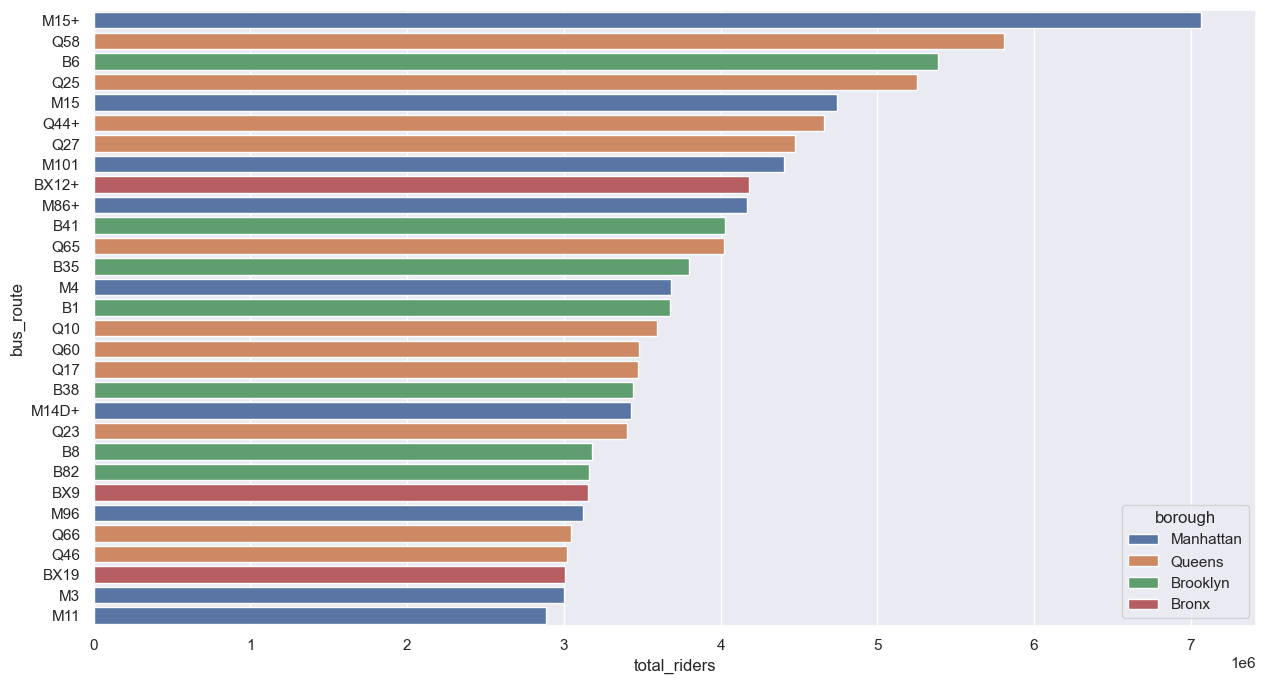

In [125]:
sns.set_theme()
plt.figure(figsize=(15, 8))
sns.barplot(
    data=bus_route_totals.head(30), x="total_riders", y="bus_route", hue="borough"
)

<Axes: xlabel='total_riders', ylabel='bus_route'>

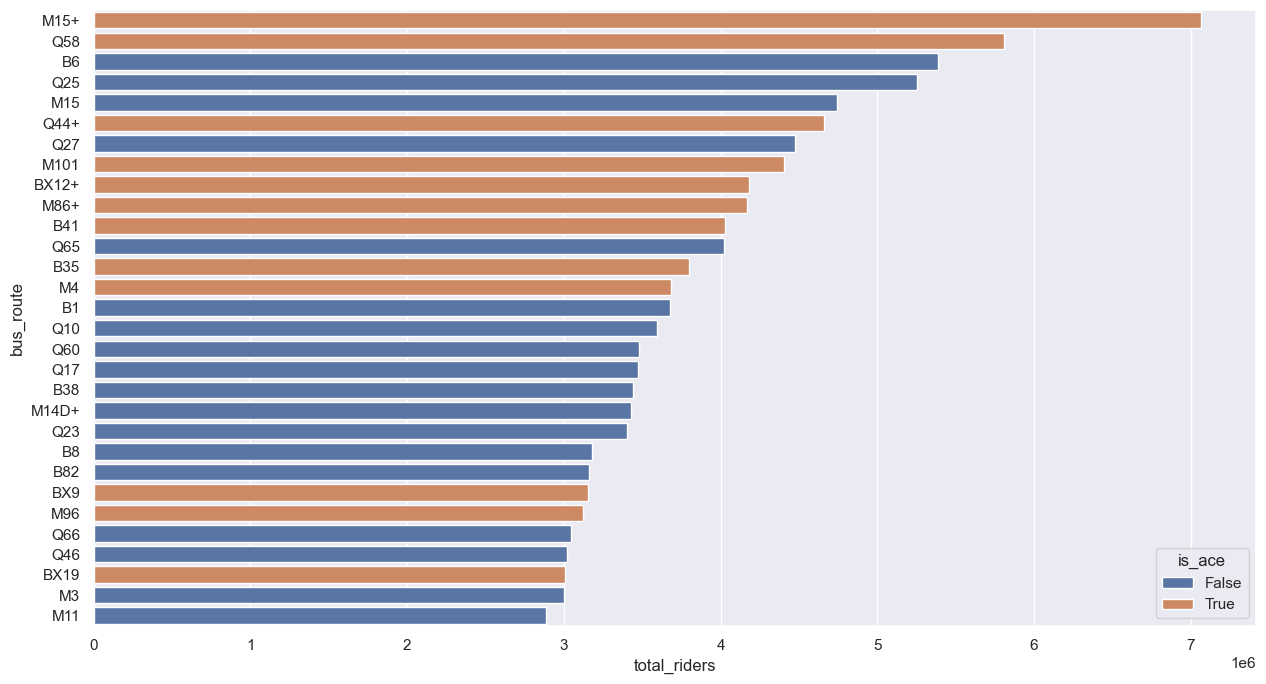

In [126]:
plt.figure(figsize=(15, 8))
sns.barplot(
    data=bus_route_totals.head(30), x="total_riders", y="bus_route", hue="is_ace"
)

<Axes: xlabel='total_riders', ylabel='borough'>

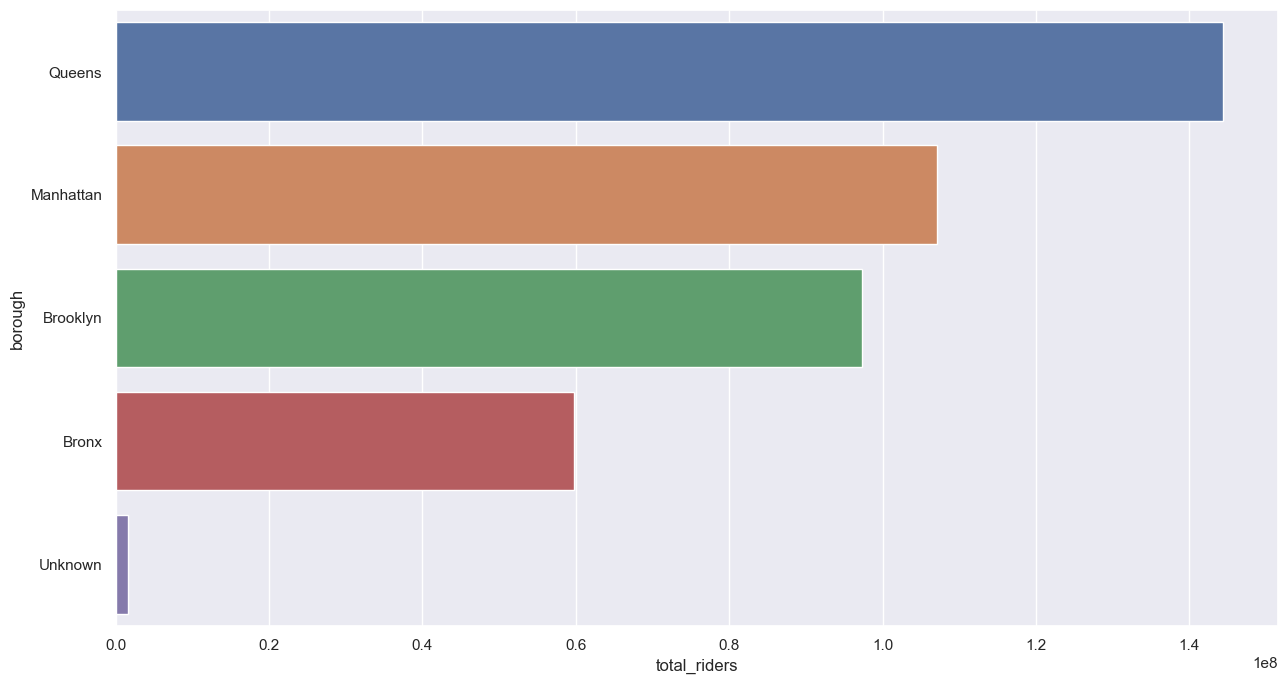

In [ ]:
sns.set_theme()
plt.figure(figsize=(15, 8))
sns.barplot(data=borough_totals, x="total_riders", y="borough", hue="borough")